The contents of this notebook were created with assistance from Claude generative AI.

# 01 · Data Prep — build & cache the rollups  *(run this first)*

This is the only notebook that touches the **big raw files**. It writes compact
**hourly-grain** rollups to `rollups/`, keyed by `(subreddit, et_date, hour)`:

- `stance_hourly` — on/off-topic **counts by stance** (from the 15 MB stance file)
- `stance_soft_hourly` — summed **class probabilities** + n (for confidence-weighted measures)
- `denom_hourly` — **total activity** counts (from the 2 GB `all_comments` + `all_posts`)

Hour grain is deliberate: day-parts, days, weeks, months are all just
re-aggregations of these — so you can re-bucket (e.g. change `DAYPARTS`) **without
re-scanning** the raw data. The expensive denominator scan is idempotent.

In [1]:
import sys; sys.path.append(".")
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()

REBUILD = False   # set True to force a full rebuild even if caches exist
print("stance file :", C.STANCE_FILE.exists(), C.STANCE_FILE)
print("all_comments:", C.ALL_COMMENTS.exists())
print("all_posts   :", C.ALL_POSTS.exists())
print("rollups dir :", C.ROLLUPS)

stance file : True GitHub Submission\Reddit\data\stance_predictions_modernbert_tuned.parquet
all_comments: True
all_posts   : True
rollups dir : GitHub Submission\Reddit\analysis\rollups


### 1a · Numerator rollups (stance counts + soft probabilities)

In [2]:
sp = C.ROLLUPS / "stance_hourly.parquet"
sf = C.ROLLUPS / "stance_soft_hourly.parquet"
if REBUILD or not sp.exists() or not sf.exists():
    items = A.load_stance_items()          # adds et_date, hour, geo, etc.
    # counts by stance
    sh = (items.groupby(["subreddit","et_date","hour","stance_pred"], observed=True)
                .size().reset_index(name="n")
                .rename(columns={"stance_pred":"stance"}))
    sh.to_parquet(sp, index=False)
    # summed probabilities (for confidence-weighted means at any grain)
    soft = (items.groupby(["subreddit","et_date","hour"], observed=True)
                  .agg(n=("id","size"),
                       sum_p_anti=("p_anti","sum"),
                       sum_p_neutral=("p_neutral","sum"),
                       sum_p_pro=("p_pro","sum"),
                       sum_p_offtopic=("p_off_topic","sum")).reset_index())
    soft.to_parquet(sf, index=False)
    print("built stance_hourly", sh.shape, "and stance_soft_hourly", soft.shape)
else:
    print("stance rollups already present — skipping (REBUILD=True to force)")

built stance_hourly (190336, 5) and stance_soft_hourly (121863, 8)


### 1b · Denominator rollup (total activity)

Scanned with **DuckDB** straight off the parquet (no full load into pandas), with
NYC-local time via the ICU extension. If ICU isn't available we fall back to a
column-pruned pandas pass. ~18.4M comments + ~1M posts — expect a minute or two
the first time, then never again.

In [3]:
dh = C.ROLLUPS / "denom_hourly.parquet"
if REBUILD or not dh.exists():
    t0 = time.time()
    def _duckdb_build():
        import duckdb
        con = duckdb.connect()
        try:
            con.execute("INSTALL icu; LOAD icu;")
        except Exception as e:
            print("  (icu unavailable:", e, ")"); raise
        q = '''
            SELECT subreddit,
                   CAST(loc AS DATE)            AS et_date,
                   CAST(EXTRACT(hour FROM loc) AS INTEGER) AS hour,
                   ? AS kind,
                   COUNT(*)                     AS n
            FROM (SELECT subreddit,
                         timezone('America/New_York', to_timestamp(created_utc)) AS loc
                  FROM read_parquet(?))
            GROUP BY 1,2,3
        '''
        parts = []
        for kind, path in [("comment", str(C.ALL_COMMENTS)), ("post", str(C.ALL_POSTS))]:
            parts.append(con.execute(q, [kind, path]).df())
            print(f"  scanned {kind}s: {parts[-1]['n'].sum():,} rows")
        return pd.concat(parts, ignore_index=True)

    def _pandas_build():
        parts = []
        for kind, path in [("comment", C.ALL_COMMENTS), ("post", C.ALL_POSTS)]:
            d = pd.read_parquet(path, columns=["subreddit","created_utc"])
            loc = A.to_local(d["created_utc"])
            g = (pd.DataFrame({"subreddit": d["subreddit"],
                               "et_date": loc.dt.normalize(),
                               "hour": loc.dt.hour})
                   .groupby(["subreddit","et_date","hour"], observed=True)
                   .size().reset_index(name="n"))
            g["kind"] = kind; parts.append(g)
            print(f"  scanned {kind}s: {int(g['n'].sum()):,} rows")
        return pd.concat(parts, ignore_index=True)

    try:
        denom = _duckdb_build()
    except Exception:
        print("  falling back to pandas pass ...")
        denom = _pandas_build()
    denom["hour"] = denom["hour"].astype(int)
    denom.to_parquet(dh, index=False)
    print(f"built denom_hourly {denom.shape} in {time.time()-t0:,.0f}s")
else:
    print("denom_hourly already present — skipping (REBUILD=True to force)")

  scanned comments: 18,408,220 rows
  scanned posts: 996,115 rows


built denom_hourly (1368499, 5) in 1s


### 1c · Validation — do the caches look right?

In [4]:
sh   = A.load_rollup("stance_hourly")
soft = A.load_rollup("stance_soft_hourly")
denom= A.load_rollup("denom_hourly")
print("stance_hourly :", sh.shape,   "| dates", sh.et_date.min().date(), "->", sh.et_date.max().date())
print("soft_hourly   :", soft.shape)
print("denom_hourly  :", denom.shape, "| total activity", f"{int(denom.n.sum()):,}")
print("\nStance totals (cache vs expected):")
print(sh.groupby("stance")["n"].sum().sort_values(ascending=False))

stance_hourly : (190336, 5) | dates 2022-12-31 -> 2026-04-30
soft_hourly   : (121863, 8)
denom_hourly  : (1368499, 5) | total activity 19,404,335

Stance totals (cache vs expected):
stance
off-topic    179418
pro          150546
anti          72400
neutral       24672
Name: n, dtype: int64


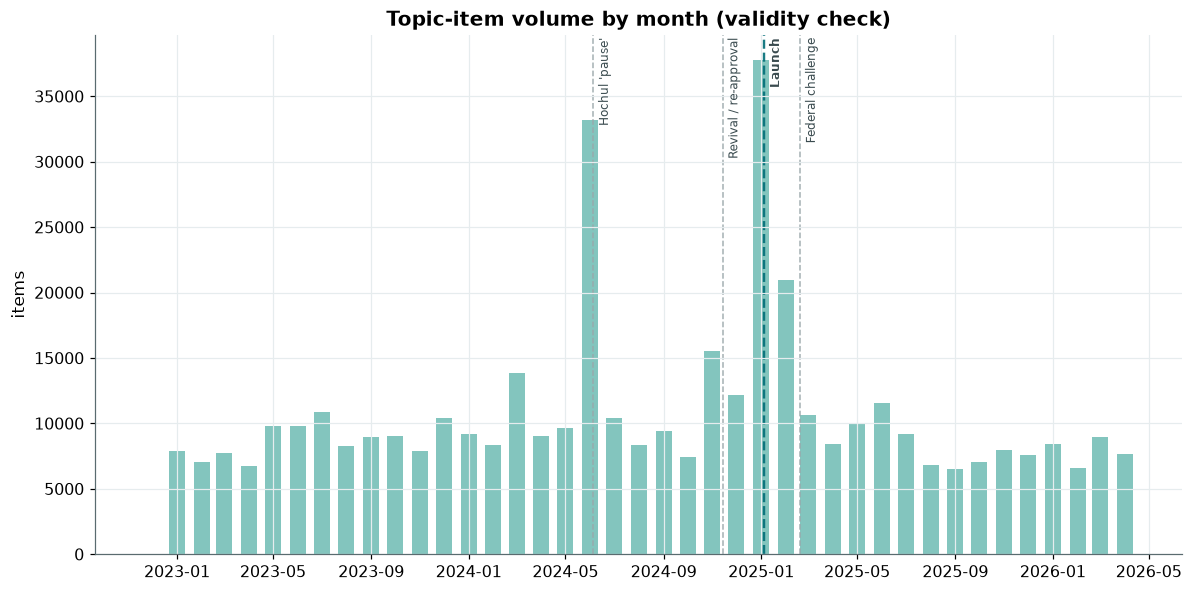

In [5]:
# Sanity check: monthly TOPIC volume should spike at the pause (Jun 2024) and
# the launch (Jan 2025) — if it doesn't, the time handling is wrong.
m = (sh.assign(period=A.time_bucket(sh.et_date,"monthly"))
       .groupby("period")["n"].sum())
fig, ax = plt.subplots()
ax.bar(m.index, m.values, width=20, color=C.PALETTE["teal"])
ax.set_title("Topic-item volume by month (validity check)"); ax.set_ylabel("items")
A.annotate_events(ax)
plt.tight_layout(); plt.show()

**Outputs written to `rollups/`:** `stance_hourly`, `stance_soft_hourly`,
`denom_hourly`. You can now run notebooks 02–07. To regenerate after the source
data changes, set `REBUILD = True` at the top and re-run.